In [11]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [12]:
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int

    strike_rate: float
    balls_per_boundary: float
    boundary_percent: float
    summary: str

In [37]:
def calculate_strike_rate(state: BatsmanState):
    strike_rate = (state['runs'] / state['balls']) * 100
    return {'strike_rate': strike_rate}

In [38]:
def calculate_balls_per_boundary(state: BatsmanState):
    balls_per_boundary = state['balls'] / (state['fours'] + state['sixes'])
    return {'balls_per_boundary': balls_per_boundary}

In [39]:
def calculate_boundary_percent(state: BatsmanState):
    boundary_percent = (((state['fours'] * 4) + (state['sixes'] * 6)) / state['runs']) * 100
    return {'boundary_percent': boundary_percent}

In [40]:
def summary(state: BatsmanState):
    summary = f"""
Strike Rate - {state['strike_rate']} \n
Balls per Boundary - {state['balls_per_boundary']} \n
Boundary Percent - {state['boundary_percent']} \n
"""
    return {'summary': summary}

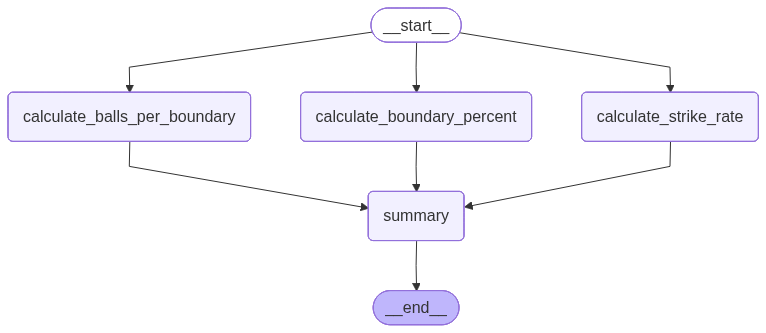

In [41]:
graph = StateGraph(BatsmanState)

graph.add_node('calculate_strike_rate', calculate_strike_rate)
graph.add_node('calculate_balls_per_boundary', calculate_balls_per_boundary)
graph.add_node('calculate_boundary_percent', calculate_boundary_percent)
graph.add_node('summary', summary) 

graph.add_edge(START, 'calculate_strike_rate')
graph.add_edge(START, 'calculate_balls_per_boundary')
graph.add_edge(START, 'calculate_boundary_percent')

graph.add_edge('calculate_strike_rate', 'summary')
graph.add_edge('calculate_balls_per_boundary', 'summary')
graph.add_edge('calculate_boundary_percent', 'summary')

graph.add_edge('summary', END)

graph.compile()

In [42]:
intial_state = {
    'runs': 250 ,
    'balls': 200,
    'fours': 20,
    'sixes': 10
}

workflow = graph.compile()

final_state = workflow.invoke(intial_state)

print(final_state)
print(final_state['summary'])

{'runs': 250, 'balls': 200, 'fours': 20, 'sixes': 10, 'strike_rate': 125.0, 'balls_per_boundary': 6.666666666666667, 'boundary_percent': 56.00000000000001, 'summary': '\nStrike Rate - 125.0 \n\nBalls per Boundary - 6.666666666666667 \n\nBoundary Percent - 56.00000000000001 \n\n'}

Strike Rate - 125.0 

Balls per Boundary - 6.666666666666667 

Boundary Percent - 56.00000000000001 


